# Проект модуля. Нейросеть для предсказания калорийности блюд
## репозиторий проекта здесь:
https://github.com/SanSanychSeva/Yandex_Practicum_DL_Engineer_2026_stream4


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from gensim.models import KeyedVectors

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2

import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

from scripts.dataset import get_text_embedding, build_data_loaders
from scripts.utils import train, two_models_history_graph, one_model_history_graph, show_top_six

# Метаданные

## флаги отладки

In [2]:
is_final_run = True

## глобальные параметры

In [3]:
# файловая структура проекта
dataset_dir = os.path.join( 'data','project')                # датасет не копируется в репозиторий из-за ограничений GitHub
word2vec_path = os.path.join('models','word2vec-google-news-300.gz')           # предзагруженная модель векторизации текста
best_models_dir = 'cfg'                                                 # здесь сохраняем веса моделей лучших эпох обучения

# параметры обучения
target_mae = 50                                 # целевая точность моделей

# Этап 1. EDA исходного датасета 

## `images` - папки с фото блюд

In [4]:
dish_list = os.listdir(os.path.join(dataset_dir,'images'))

print('FYI: всего папок с фото блюд', len(dish_list), ', примеры названий папок:\n', dish_list[:5])

FYI: всего папок с фото блюд 3490 , примеры названий папок:
 ['dish_1556572657', 'dish_1556573514', 'dish_1556575014', 'dish_1556575083', 'dish_1556575124']


### проверим, по скольку фото на одно блюдо присутствует в датасете

In [5]:
nof_photos = []
for dish in dish_list:
    nof_photos.append(
        len(os.listdir(os.path.join(dataset_dir, 'images', dish)))
    )

pd.Series(nof_photos).value_counts(dropna=False)

1    3490
Name: count, dtype: int64

### проверим разрешение всех файлов

In [6]:
photo_shapes = []
photo_samples = []
for dish in tqdm(dish_list):
    f_name = os.listdir(os.path.join(dataset_dir, 'images', dish))[0]
    img = Image.open(os.path.join(dataset_dir, 'images', dish, f_name)).convert("RGB")
    photo_shapes.append(np.array(img).shape)
    if np.random.choice([1]+[0]*(len(dish_list)//10)):  # берем вероятность так, чтобы выбрать примерно 10 блюд для показа
        photo_samples.append((dish, img))

pd.Series(photo_shapes).value_counts(dropna=False)

100%|██████████| 3490/3490 [00:31<00:00, 112.36it/s]


(480, 640, 3)    3490
Name: count, dtype: int64

**ВЫВОДЫ:**
* на одно блюдо в датасете строго одно фото
* все фото имеют одинаковый размер массива пикселей (480, 640, 3) - (H, W, C)

### посмотрим на случайно выбранные картинки блюд

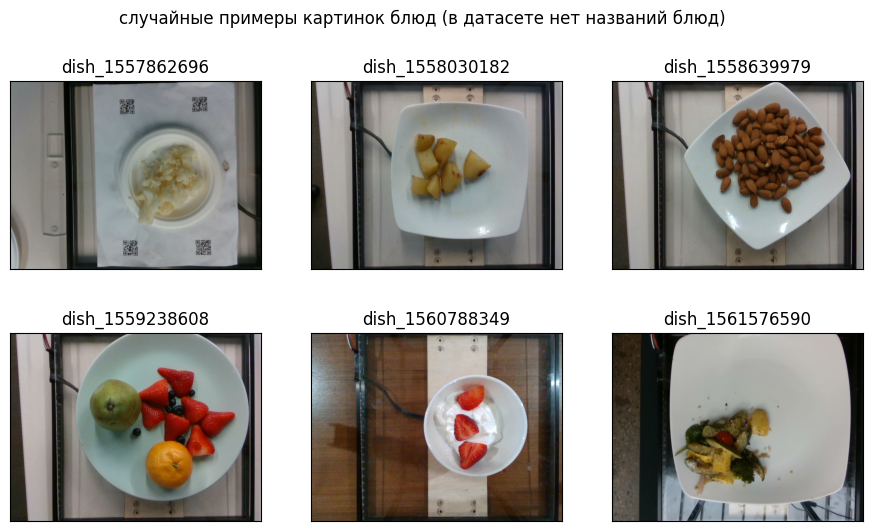

In [7]:
fig, axes = plt.subplots(2,3, figsize=(11,6))
axes = axes.flatten()

for i,ax in enumerate(axes):
    if i < len(photo_samples):
        ax.imshow(photo_samples[i][1])
        ax.set_title(photo_samples[i][0])
    ax.set_xticks([])
    ax.set_yticks([])
    
fig.suptitle('случайные примеры картинок блюд (в датасете нет названий блюд)')
plt.show()

## `dish.csv` - список блюд

In [8]:
# сразу зафиксируем порядок записей в таблице блюд (в том числе, удобным для train-test-split образом):
dish_df = pd.read_csv(os.path.join(dataset_dir,'dish.csv')).sort_values(['split','dish_id']).reset_index(drop=True)

dish_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.5+ KB


**НАБЛЮДЕНИЕ:** записей меньше, чем папок

In [9]:
dish_df.sample(5, axis=0)

,dish_id,total_calories,total_mass,ingredients,split
1560,dish_1561580370,126.795876,124.0,ingr_0000000036;ingr_0000000514;ingr_000000005...,train
1131,dish_1559844611,55.889999,81.0,ingr_0000000440,train
184,dish_1560801883,512.111267,315.0,ingr_0000000515;ingr_0000000244;ingr_000000047...,test
599,dish_1558116146,76.589996,111.0,ingr_0000000440,train
2878,dish_1565981802,99.754425,152.0,ingr_0000000045;ingr_0000000291;ingr_000000005...,train


**НАБЛЮДЕНИЕ:** значения `dish_id` похожи на именования папок с фото блюд

In [10]:
dish_df.dish_id.value_counts(dropna=False).head()         # проверим уникальность dish_id (все частоты в топе равны 1)

dish_id
dish_1556575327    1
dish_1563294522    1
dish_1563221640    1
dish_1563222745    1
dish_1563222775    1
Name: count, dtype: int64

### а все ли блюда есть в списках и на фото?

In [11]:
counter = 0

for dish in list(dish_df.dish_id):
    if dish not in dish_list:
        counter += 1

if counter == 0:
    print('FYI: All dishes in dish.csv(field "dish_id") are present in dish dir list')
else:
    print('FYI:', counter, 'out of', len(dish_df), 'dishes in dish.csv(field "dish_id") are missing in dish dir list')

counter = 0

for dish in dish_list:
    if dish not in list(dish_df.dish_id):
        counter += 1

if counter == 0:
    print('FYI: All dishes in dish dir list are present in dish.csv(field "dish_id")')
else:
    print('FYI:', counter, 'out of', len(dish_list), 'dishes in dish dir list are missing in dish.csv(field "dish_id")')

FYI: All dishes in dish.csv(field "dish_id") are present in dish dir list
FYI: 228 out of 3490 dishes in dish dir list are missing in dish.csv(field "dish_id")


In [12]:
len(dish_df) + counter,  len(dish_list)     # проверяем возможные причины - должны совпасть!

(3490, 3490)

**ВЫВОДЫ:**
* 228 папок с фото лишние в датасете - для них нет информации в списке блюд
* для всех блюд в списке есть папка с фото (поэтому лишние фото не помешают строить детесет, исходя из списка блюд)

## `ingredients.csv` - список ингредиентов

In [13]:
ingr_df = pd.read_csv(os.path.join(dataset_dir,'ingredients.csv')).sort_values('id').reset_index(drop=True)

ingr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


In [14]:
ingr_df.head()

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


In [15]:
ingr_df.id.value_counts(dropna=False).head()                 # проверим уникальность id (все частоты в топе равны 1)

id
1      1
373    1
367    1
368    1
369    1
Name: count, dtype: int64

### ID ингредиентов имеют разный формат в двух таблицах, проверим предполагаемое мнемоническое правило:
если в поле `ingredients` списка блюд отбросить все знаки левее первой отличной от нуля цифры, то получим целый ID из `indredients.csv` колонка `id`

In [16]:
dish_df['dish_ingr_list'] = dish_df.ingredients.map(lambda s: s.strip().split(';'))   # конвертим строку в список

In [17]:
dish_df.dish_ingr_list = dish_df.dish_ingr_list.map(pd.Series).map(                       # конвертим список в серию пандас
                            lambda ser: ser.map(                                          # к каждой серии применяем map()
                                lambda s: int(re.sub(r"^0+", "", re.sub(r"\D", "", s)))   # с регулярным выражением и 
                            )                                                             # конвертим остаток в целый тип
                        ).map(list)                                                       # возвращаем тип список (целых)

**NB!:** теперь предполагается, что поле `dish_ingr_list` содержит списки целочисленных ID ингредиентов из таблицы таковых (поле `id`)

In [18]:
dish_df.sample(5, axis=0)

,dish_id,total_calories,total_mass,ingredients,split,dish_ingr_list
2981,dish_1566501126,564.917969,369.0,ingr_0000000036;ingr_0000000045;ingr_000000014...,train,"[36, 45, 148, 12, 28, 42]"
2602,dish_1564690138,190.499496,181.0,ingr_0000000213;ingr_0000000122;ingr_000000035...,train,"[213, 122, 357, 515, 43, 524, 520, 161, 291, 1..."
2619,dish_1564777986,372.230896,221.0,ingr_0000000011;ingr_0000000027;ingr_000000016...,train,"[11, 27, 161, 511, 133, 94, 189, 291, 513, 525..."
1522,dish_1561576978,511.614227,341.0,ingr_0000000133;ingr_0000000124;ingr_000000051...,train,"[133, 124, 519, 28, 515, 161, 126, 46, 516, 33..."
840,dish_1558640748,14.500000,58.0,ingr_0000000007,train,[7]


### все ли ингрединенты из таблицы ингредиентов используются при приготовлении блюд из списка блюд?

In [19]:
ingr_list = list(set(dish_df.dish_ingr_list.sum()))

len(ingr_list)

200

**НАБЛЮДЕНИЕ:** уже точно видно, что используются не все - в списке блюд менее половины ингредиентов (по количеству) из таблицы последних

In [20]:
counter = 0

for ingr in ingr_list:
    if ingr not in list(ingr_df.id):
        counter += 1

if counter == 0:
    print('FYI: All ingrs in dish used ingr list are present in ingredients.csv(field "id")')
else:
    print('FYI:', counter, 'out of', len(ingr_list), 
          'ingrs in dish used ingr list are missing in ingredients.csv(field "id")')
    
counter = 0

for ingr in list(ingr_df.id):
    if ingr not in ingr_list:
        counter += 1

if counter == 0:
    print('FYI: All ingrs in ingredients.csv(field "id") are present in dish used ingr list')
else:
    print('FYI:', counter, 'out of', len(ingr_df), 
          'ingrs in ingredients.csv(field "id") are missing in dish used ingr list')

FYI: All ingrs in dish used ingr list are present in ingredients.csv(field "id")
FYI: 355 out of 555 ingrs in ingredients.csv(field "id") are missing in dish used ingr list


In [21]:
len(ingr_df),  len(ingr_list) + counter     # проверяем возможные причины - должны совпасть!

(555, 555)

**ВЫВОДЫ:**
* 355 ингредиентов являются лишними степенями свободы для векторизации состава блюд в датасете - их лучше удалить
* для всех ингредиентов, использованных в списке блюд есть запись в таблице ингредиентов с текстовым полем названия

In [22]:
ingr_df = ingr_df.query('id in @ingr_list').reset_index(drop=True)

ingr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      200 non-null    int64 
 1   ingr    200 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.2+ KB


## далее можно добавить всю информацию в таблицу блюд и более уже не возвращаться к таблице ингредиентов

#### векторизация блюд по используемым ингредиентам

In [23]:
V_ingr_ij = np.array(
    [
        [ int(i in dish_df.dish_ingr_list[j]) for i in list(ingr_df.id) ]
        for j in range(len(dish_df))
    ]
)

V_ingr_ij.shape

(3262, 200)

собственно, вливать эту numpy-матрицу в панда-датасет нет необходимости, так как использовать его можно напрямую.  Важно лишь что между `dish_df` и `V_ingr_ij` есть соответствие по первому индексу, которое всегда можно восстановить:

In [24]:
dish_df[['dish_id', 'split']].join(pd.DataFrame(V_ingr_ij)).sample(10, axis=0)

,dish_id,split,0,1,2,3,4,5,6,7,...,190,191,192,193,194,195,196,197,198,199
3110,dish_1567110665,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
409,dish_1565638515,test,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1757,dish_1562097673,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
759,dish_1558632799,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
123,dish_1559578579,test,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2754,dish_1565640272,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2340,dish_1563565761,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
592,dish_1558115764,train,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2691,dish_1565195362,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
867,dish_1558718009,train,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


матрица `V_ingr_ij` достаточно спарсная, но ее размеры не мешают хранить ее в плотном виде (имея ввиду дополнить ее другими неспарсными полями при моделировании)

In [25]:
print('FYI: степень заполненности матрицы векторизации блюд по ингредиентам =', 
      round(V_ingr_ij.sum() / V_ingr_ij.shape[0] / V_ingr_ij.shape[1] *100, 2), '%')

FYI: степень заполненности матрицы векторизации блюд по ингредиентам = 3.66 %


#### текстовое описание состава блюд

In [26]:
dish_df['descr'] = dish_df.dish_ingr_list.map(lambda lst:
                        ' '.join([ ingr_df.query('id == @n').iloc[0,1] for n in lst ])
                    )

In [27]:
dish_df.drop(columns=['ingredients']).sample(10, axis=0)

,dish_id,total_calories,total_mass,split,dish_ingr_list,descr
1043,dish_1559319971,72.959999,96.0,train,[437],sweet potato
469,dish_1566838351,190.009995,417.0,test,"[13, 121, 38]",berries watermelon pineapple
1558,dish_1561580278,23.320000,53.0,train,[6],caesar salad
2244,dish_1563391681,154.317169,143.0,train,"[49, 201, 189, 515, 517, 94, 82, 161, 122, 523...",fish blueberries vinegar arugula chard onions ...
871,dish_1558719040,31.960001,94.0,train,[37],cantaloupe
2191,dish_1563303350,202.221436,167.0,train,"[28, 45, 36, 524, 514, 518, 161, 520, 312, 291...",chicken carrot spinach (raw) parsley wheat ber...
1028,dish_1559244417,72.832504,59.0,train,"[312, 517, 201, 189, 515, 161, 126, 124, 291]",pepper chard blueberries vinegar arugula olive...
2833,dish_1565808975,35.720001,130.0,train,"[471, 94]",cherry tomatoes onions
149,dish_1560367952,414.733154,221.0,test,"[49, 36, 380, 94, 534, 161, 291, 122, 535]",fish spinach (raw) pizza onions country rice o...
2584,dish_1564675193,478.808777,803.0,train,"[440, 121, 128, 437, 161]",grapes watermelon egg whites sweet potato oliv...


## статистика полей датасета блюд

### train-test split

In [28]:
pd.DataFrame(
    [dish_df.split.value_counts(dropna=False), dish_df.split.value_counts(dropna=False, normalize=True)*100]
).T.map(round)

,count,proportion
split,,
train,2755,84
test,507,16


### блюда с нулевым составом

In [29]:
pd.DataFrame(
    index=['calories > 0','mass > 0'],
    data=[
        dish_df.total_calories.map(lambda d: d > 0).value_counts(dropna=False),
        dish_df.total_mass.map(lambda d: d > 0).value_counts(dropna=False)
    ]
).T

,calories > 0,mass > 0
True,3260.0,3262.0
False,2.0,NaN


### посмотрим на веса и калорийность блюд в датасете

C:\Users\aseva\AppData\Local\Temp\ipykernel_2864\2068803698.py:5: RuntimeWarning: divide by zero encountered in log
  axes[1].hist(dish_df.total_calories.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])


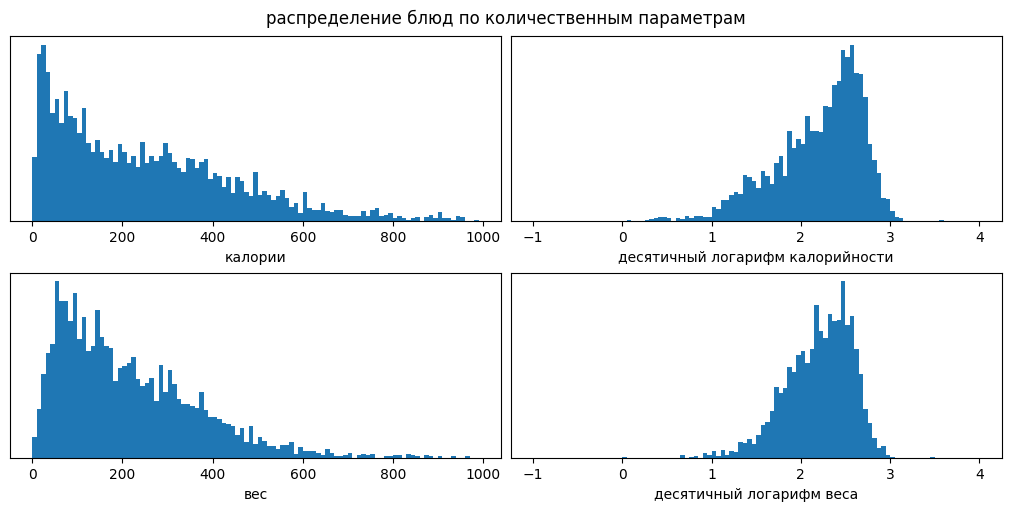

In [30]:
fig, axes = plt.subplots(2,2, figsize=(10,5), layout='constrained')
axes = axes.flatten()

axes[0].hist(dish_df.total_calories, bins=range(0,1000,10))
axes[1].hist(dish_df.total_calories.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])

axes[2].hist(dish_df.total_mass, bins=range(0,1000,10))
axes[3].hist(dish_df.total_mass.map(lambda d: np.log(d)/np.log(10.0)), bins=[-1 + 0.05*i for i in range(101)])

for i in range(4): axes[i].set_yticks([])
axes[0].set_xlabel('калории')
axes[2].set_xlabel('вес')
axes[1].set_xlabel('десятичный логарифм калорийности')
axes[3].set_xlabel('десятичный логарифм веса')

fig.suptitle('распределение блюд по количественным параметрам')
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
* распределения ближе к логнормальным
* однако спешить переходить к логарифмам не стоит, так как в природе самих параметров заложена аддитивность по отношению к целевой переменной, а не мультипликативность. Поэтому есть надежда сделать более точный baseline на аддитивных параметрах

### посмотрим на частотность ингредиентов в блюдах

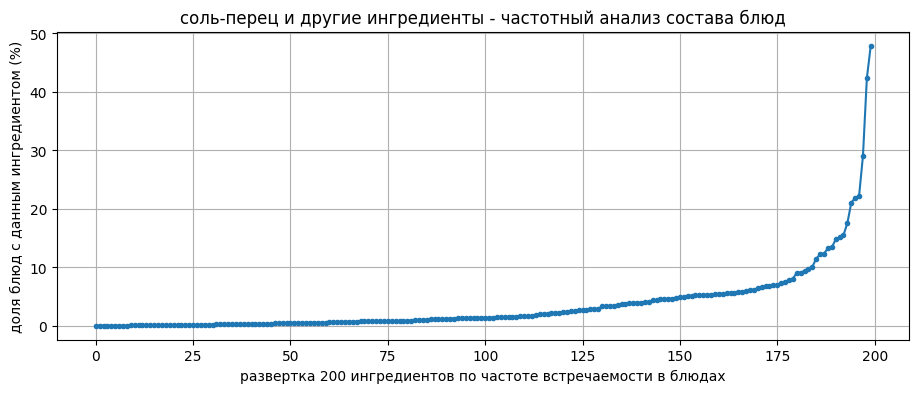

In [31]:
y = np.sort(V_ingr_ij.sum(axis=0)/len(dish_df)*100)    # делаем развертку по частоте
plt.figure(figsize=(11,4))
plt.plot(y, marker='.')
plt.ylabel('доля блюд с данным ингредиентом (%)')
plt.xlabel('развертка 200 ингредиентов по частоте встречаемости в блюдах')
plt.title('соль-перец и другие ингредиенты - частотный анализ состава блюд')
plt.grid()
plt.show()

**ВЫВОДЫ ИЗ ГРАФИКОВ:**
как видим, компоненты вектора разномасштабные - не забыть про нормализацию!

# Baseline models

In [32]:
baseline = {}

## готовим данные

In [33]:
Xy = np.concatenate([dish_df[['total_calories','total_mass']].values, V_ingr_ij], axis=1)
y = Xy[:,0]
X = Xy[:,1:]

X.shape, y.shape

((3262, 201), (3262,))

### нормализуем только предикторы

In [34]:
scaler_ml = StandardScaler()

X_norm = scaler_ml.fit_transform(X)

### разделяем трейн и тест выборки

In [35]:
X_test = X_norm[:(dish_df.split == 'test').sum()]        # мы сразу упорядочили dish_df по полю split
X_train = X_norm[(dish_df.split == 'test').sum():]

y_test = y[:(dish_df.split == 'test').sum()]
y_train = y[(dish_df.split == 'test').sum():]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2755, 201), (2755,), (507, 201), (507,))

## линейная регрессия - Least Square Plane

In [36]:
baseline['linear'] = LinearRegression()
baseline['linear'].fit(X_train,y_train)
y_pred = baseline['linear'].predict(X_test)

print('Baseline model LR results on test data:')
print('MAE =', round(MAE(y_test, y_pred),2), 'калорий')
print('RMSE =', round(np.sqrt(MSE(y_test, y_pred)),2), 'калорий')
print('R2 =', round(R2(y_test, y_pred)*100,2), '%')

Baseline model LR results on test data:
MAE = 56.45 калорий
RMSE = 89.1 калорий
R2 = 82.34 %


**ВЫВОДЫ:**
* хоть мы значительно не дотягиваем до целевого MAE (50), линейная регрессия, как обычно, хороша интерпретацией результата: по факту, она дает нам в своих весах рецепты блюд - если нормировать их на суммарную калорийность total_calories, то веса прямо дадут нам ответ, сколько взять каждого ингредиента в калориях
* обычно мы измеряем ингредиенты в граммах - если взять за целевую переменную total_mass, то веса дадут количества ингредиентов в граммах

## ансамбли решающих деревьев - Histogram-based Gradient Boosting Regression Tree

In [37]:
baseline['HGBoost'] = HistGradientBoostingRegressor()
baseline['HGBoost'].fit(X_train,y_train)
y_pred = baseline['HGBoost'].predict(X_test)

print('Baseline model HGB results on test data:')
print('MAE =', round(MAE(y_test, y_pred),2), 'калорий')
print('RMSE =', round(np.sqrt(MSE(y_test, y_pred)),2), 'калорий')
print('R2 =', round(R2(y_test, y_pred)*100,2), '%')

Baseline model HGB results on test data:
MAE = 51.73 калорий
RMSE = 88.56 калорий
R2 = 82.56 %


**ВЫВОДЫ:**
* мы почти достигли целевого MAE (50) - без DL и без генерации DL-фич !
* фокус в том, что состав блюд по ингредиентам и вес - это уже сами по себе релевантные фичи для задачи калорийности
* более того, наша векторизация по id ингредиентов, по факту, является наиболее релевантной задаче семантической токинезацией текстового описания - вряд ли вектор с токинезаций и эмбеддингом по общеязыковому Word2Vec алгоритму будет более имманентен задаче.  Едиственно, что может добавить Word2Vec fkujhbnv к нашей векторизации по ингредиентам, - это учесть синонимы одного и того же ингредиента с близкой калорийностью - например, говядина и телятина, или курица и цыпленок, или булочка и хлеб, ну или сыграть на семантической аддитивности Word2Vec-векторов: типа, сэндвич коллинеарен (хлеб + ветчина + сыр).
* маловероятно, что DL-фичи, экстрактированные предобученными моделями из фото или текстового описания ингредиентов блюд, будут более релевантными задаче, чем уже использованные,  - в лучшем случае они добавят чуть больше дополнительной точности, чем привнесут шума!
* но мне уже просто интересно, сколько по-максимуму можно выжать из табличных фич и ингредиентной векторизации - поэтому попробуем еще один бейслайн - полносвязную нейронку с механизмами борьбы с переобучением на коротком датасете:  

## полносвязная нейронная сеть для регрессии - MLP regressor

### собираем загрузчик данных

In [38]:
train_loader, test_loader = build_data_loaders(X_norm, 
                                               dish_df.total_calories.values, 
                                               round((dish_df.split == 'test').sum()))

### собираем архитектуру сети

In [39]:
for batch in test_loader:
    input_size = batch[0].shape[1]
    break

model = nn.Sequential(
    nn.Linear(input_size, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(p=0.1),

    nn.Linear(64, 1)
)

criterion = nn.L1Loss()                              # MAE

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### цикл обучения минибатчами

In [40]:
epochs_history, best_MAE, best_model = train(model, criterion, optimizer, train_loader, test_loader)

Epoch No   0  |  Train MAE = 254.01  |  Validation MAE = 255.2
Epoch No  20  |  Train MAE = 217.2  |  Validation MAE = 215.53
Epoch No  40  |  Train MAE = 124.11  |  Validation MAE = 129.88
Epoch No  60  |  Train MAE = 37.1  |  Validation MAE = 58.53
Epoch No  80  |  Train MAE = 29.94  |  Validation MAE = 49.36
Epoch No 100  |  Train MAE = 27.48  |  Validation MAE = 45.73
Epoch No 120  |  Train MAE = 26.1  |  Validation MAE = 45.58
Epoch No 140  |  Train MAE = 25.3  |  Validation MAE = 45.69
Epoch No 160  |  Train MAE = 23.49  |  Validation MAE = 42.84
Epoch No 180  |  Train MAE = 23.45  |  Validation MAE = 43.18
Epoch No 200  |  Train MAE = 23.33  |  Validation MAE = 42.07
Epoch No 220  |  Train MAE = 21.85  |  Validation MAE = 42.74
Epoch No 240  |  Train MAE = 24.2  |  Validation MAE = 43.77
Epoch No 260  |  Train MAE = 23.21  |  Validation MAE = 42.03
Epoch No 280  |  Train MAE = 24.2  |  Validation MAE = 42.28
Epoch No 300  |  Train MAE = 21.6  |  Validation MAE = 42.03
Epoch No 3

### визуализация обучения по эпохам

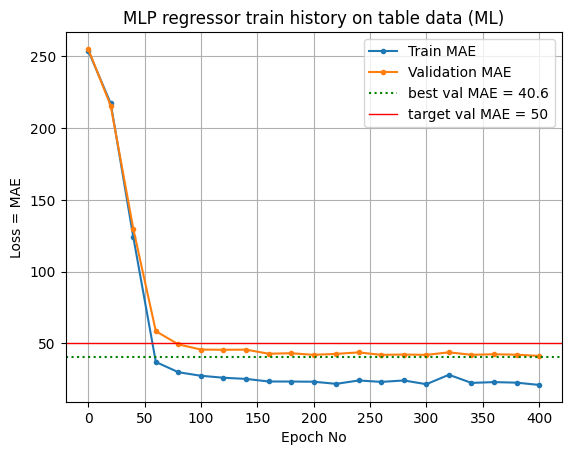

In [41]:
one_model_history_graph(epochs_history, best_MAE, target_mae)

## ВЫВОДЫ ПО BASELINE МОДЕЛЯМ:
* когнитивные способности одержали верх над комбинаторными - лучшая baseline модель получилась на основе скромного перцептрона с двумя скрытыми слоями и (201 + 1) * 256 + (256 + 1) * 64 + 64 + 1 = 68225 параметрами: она достигла уровня МАЕ=40 без использования DL-фич, обычным табличным ML:
  * Линейная регрессия MAE = 56
  * GBoost ансамбли MAE = 52
  * Полносвязная NN MAE = 41 +/- 2
* устранить флуктуации точности MLP-модели принципиально нельзя, так как это оборотная сторона механизмов удержания модели от переобучения - мы включили финальный dropout на 64 нейрона перед выходным слоем
* для максимального уменьшения флуктуаций асимптотической точности обучения мы увеличили размеры (мини)батча и снизили вероятность dropout.  Уменьшение шага обучения только ухудшает асимптотическую точность не снижая флуктуации, но замедляя скорость обучение - видимо, малый шаг мешает выскакивать траектории обучения из локальных экстремумов 
* снижать флуктуации асимптотической точности еще ниже не имеет смысла, так как у валидационной выборки также есть ограничения ее репрезентативности при размерах в 507 объектов.  Предельную сигму влияния отклонения валидационной выборки от репрезентативности можно грубо оценить как 41 / sqrt(507) = 1.8 - это наши уже достигнутые +/- 2 флуктуации

# Дальнейший план по DL-обучению
* будем использовать предобученные DL модели (NLP и CV) как дополнительные feature-extractor-ы:
  * для текстового описания возьмем обученный текстовый эмбеддинг с семантической векторизацией
  * для фото используем готовую сетку из torch-vision, которую уже успешно опробовали в проекте стрима 3
* далее конкатенируем все группы фич в общую матрицу (объекты, фичи) и опять применим полносвязную сеть, которую обучим сами.
* кажется, что можно возразить против такого подхода: но где же аугментация изображений внутри дата-лодера, без которой, как известно, хорошо обучить сверточные слои невозможно.  Однако, мы и не собираемся дообучать сверточные слои - мы собираемся переиспользовать обученные модели как генераторы финальных фич - то есть, если предобучение сверточных слоев (на аугментированных данных) прошло удачно, финальные фичи уже не зависят существенным образом от аугментации - а значит, они должны давать приблизительно один и тот же вектор фич для всех аугментаций одного и того же изображения
* все решит эксперимент - посмотрим что получится при нашем подходе, и позволит ли он достичь MAE = 50 - тем более, что в реалиях моей работы такой вариант мультимодальных моделей куда более практичен для применения полученных на курсе знаний, чем амбициозное full-multimodal (пере)обучение DL-слоев, для которого у нас и платформ-то в наличии нет!

# Этап 2. Генерация мультимодальных фич, подготовка датасета и батчевого загрузчика

## NLP-features generation

In [42]:
# загружаем веса текстовой модели
google_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True) 


In [43]:
text_list = list(dish_df.descr.map(lambda s: s.replace('(','').replace(')','').split()))

V_w2v = []
for i in range(len(dish_df)):
    V_w2v.append(get_text_embedding(text_list[i], w2v_model=google_model))

V_w2v = np.array(V_w2v)

V_w2v.shape, V_w2v.dtype, type(V_w2v)

((3262, 300), dtype('float32'), numpy.ndarray)

In [44]:
scaler_w2v = StandardScaler()

V_w2v_norm = scaler_w2v.fit_transform(V_w2v)

## CV-features generation

In [45]:
cv_weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1

cv_model = mobilenet_v3_small(weights=cv_weights)

cv_model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [46]:
f_name = 'rgb.png'
cv_preprocess = cv_weights.transforms()    # возьмем предобработку из загруженной модели

V_cv = []
for i in tqdm(range(len(dish_df))):

    img = Image.open(os.path.join(dataset_dir, 'images', dish_df.dish_id[i], f_name)).convert("RGB")
    x = cv_preprocess(img).unsqueeze(0)

    with torch.no_grad():
        f = cv_model.features(x)
        f = cv_model.avgpool(f)
        f = torch.flatten(f, 1)[0].detach().numpy()
    
    V_cv.append(f)
    
V_cv = np.array(V_cv)

V_cv.shape, V_cv.dtype, type(V_cv)

100%|██████████| 3262/3262 [00:59<00:00, 54.44it/s]


((3262, 576), dtype('float32'), numpy.ndarray)

In [47]:
scaler_cv = StandardScaler()

V_cv_norm = scaler_cv.fit_transform(V_cv)

## собираем пайплайн загрузки данных для обучения и валидации

In [48]:
train_loader_dl, test_loader_dl = build_data_loaders(
                                      [X_norm.astype(np.float32)[:,:1], V_w2v_norm, V_cv_norm],           # оставляем массу
                                      dish_df.total_calories.values, 
                                      round((dish_df.split == 'test').sum())
                                      )

# Этап 3. Обучение модели

## собираем архитектуру модели

In [49]:
for batch in test_loader_dl:
    input_size = batch[0].shape[1]
    break

model_dl = nn.Sequential(
    nn.Linear(input_size, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),

    nn.Linear(1024, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.5),

    nn.Linear(128, 1)
)

criterion_dl = nn.L1Loss()                                # MAE

optimizer_dl = torch.optim.Adam(model_dl.parameters(), lr=0.001)

## цикл обучения минибатчами

In [50]:
epochs_history_dl, best_MAE_dl, best_model_dl = train(model_dl, criterion_dl, optimizer_dl, train_loader_dl, test_loader_dl)

Epoch No   0  |  Train MAE = 254.1  |  Validation MAE = 254.29
Epoch No  20  |  Train MAE = 177.6  |  Validation MAE = 179.46
Epoch No  40  |  Train MAE = 43.48  |  Validation MAE = 56.04
Epoch No  60  |  Train MAE = 35.08  |  Validation MAE = 51.39
Epoch No  80  |  Train MAE = 28.7  |  Validation MAE = 51.53
Epoch No 100  |  Train MAE = 28.49  |  Validation MAE = 48.04
Epoch No 120  |  Train MAE = 29.68  |  Validation MAE = 48.62
Epoch No 140  |  Train MAE = 29.16  |  Validation MAE = 49.07
Epoch No 160  |  Train MAE = 27.59  |  Validation MAE = 49.71
Epoch No 180  |  Train MAE = 27.69  |  Validation MAE = 49.43
Epoch No 200  |  Train MAE = 29.17  |  Validation MAE = 48.77
Epoch No 220  |  Train MAE = 28.4  |  Validation MAE = 51.12
Epoch No 240  |  Train MAE = 27.89  |  Validation MAE = 49.0
Epoch No 260  |  Train MAE = 26.97  |  Validation MAE = 50.0
Epoch No 280  |  Train MAE = 28.42  |  Validation MAE = 49.01
Epoch No 300  |  Train MAE = 28.53  |  Validation MAE = 49.46
Epoch No 3

## визуализация обучения по эпохам

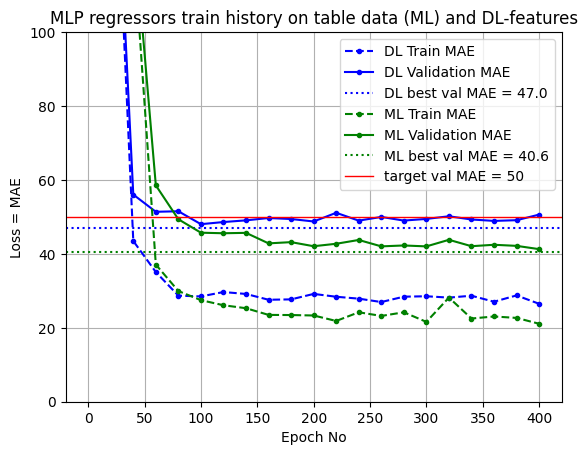

In [51]:
two_models_history_graph(epochs_history_dl, epochs_history, best_MAE_dl, best_MAE, target_mae)

# Этап 4. Валидация качества
для сравнения будем использовать baseline модель на компонентной векторизации блюд в сопоставлении с мультимодальной моделью на базе текстового описания и фото блюд

## зафиксируем модели для инференса при оценке качества
загружаем предварительно сохраненные модели лучших эпох обучения - когда флаг `is_final_run = True`, переписывания сохраненных моделей при повторных прогонах блокнота более на происходит.  Это позволяет подобрать оптимальный вариант обучения и заморозить его для анализа в этой главе

In [52]:
if not is_final_run:
    torch.save(best_model.state_dict(), os.path.join(best_models_dir, "best_model.pt"))
    torch.save(best_model_dl.state_dict(), os.path.join(best_models_dir, "best_model_dl.pt"))
    print('FYI: best models weights saved to', best_models_dir)

In [53]:
model.load_state_dict(torch.load(os.path.join(best_models_dir, "best_model.pt")))
model.eval()

Sequential(
  (0): Linear(in_features=201, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=64, bias=True)
  (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.1, inplace=False)
  (7): Linear(in_features=64, out_features=1, bias=True)
)

In [54]:
model_dl.load_state_dict(torch.load(os.path.join(best_models_dir, "best_model_dl.pt")))
model_dl.eval() 

Sequential(
  (0): Linear(in_features=877, out_features=1024, bias=True)
  (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=1024, out_features=128, bias=True)
  (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=128, out_features=1, bias=True)
)

## согласно условиям проекта инференс делаем на тестовой части исходного датасета
поскольку у нас в классе датасета не определялся метод для среза данных, воспользуемся батчевым загрузчиком с длиной батча на все тестовые данные - мы благоразумно упорядочили исходный датасет по полю `split`, так что сперва в датасете идут все тестовые объекты.

In [55]:
_, val_loader_ml = build_data_loaders(X_norm, 
                                     dish_df.total_calories.values, 
                                     round((dish_df.split == 'test').sum()),
                                     test_batch_size=round((dish_df.split == 'test').sum()))

for ml_batch in val_loader_ml:
    break

X_inf_ml = ml_batch[0]
X_inf_ml.shape

torch.Size([507, 201])

In [56]:
_, val_loader_dl = build_data_loaders([X_norm.astype(np.float32)[:,:1], V_w2v_norm, V_cv_norm], 
                                     dish_df.total_calories.values, 
                                     round((dish_df.split == 'test').sum()),
                                     test_batch_size=round((dish_df.split == 'test').sum()))

for dl_batch in val_loader_dl:
    break

X_inf_dl = dl_batch[0]
X_inf_dl.shape

torch.Size([507, 877])

## результаты инференса соберем в виде табличного датасета

In [57]:
inf_df = dish_df.query('split == "test"').copy('deep')
inf_df['path_to_photo'] = inf_df.dish_id.map(lambda s: os.path.join(dataset_dir, 'images', s, 'rgb.png'))
inf_df = inf_df[['total_mass','descr','path_to_photo','total_calories']].copy('deep')
inf_df.head()

,total_mass,descr,path_to_photo,total_calories
0,152.0,celery olives brussels sprouts,data\project\images\dish_1556575327\rgb.png,103.300003
1,1.0,plate only,data\project\images\dish_1557861216\rgb.png,0.000000
2,63.0,chicken,data\project\images\dish_1557862345\rgb.png,103.949997
3,77.0,cauliflower,data\project\images\dish_1557862696\rgb.png,19.250000
4,118.0,steak,data\project\images\dish_1557862738\rgb.png,319.779999


### теперь докидываем предсказания моделей

In [58]:
inf_df['baseline_pred'] = model(X_inf_ml).detach().numpy().flatten()
inf_df['multimodal_pred'] = model_dl(X_inf_dl).detach().numpy().flatten()
inf_df['baseline_MAE'] = (inf_df.total_calories - inf_df.baseline_pred).map(abs)
inf_df['multimodal_MAE'] = (inf_df.total_calories - inf_df.multimodal_pred).map(abs)
inf_df.drop(columns=['path_to_photo']).head()

,total_mass,descr,total_calories,baseline_pred,multimodal_pred,baseline_MAE,multimodal_MAE
0,152.0,celery olives brussels sprouts,103.300003,97.674011,108.185646,5.625992,4.885643
1,1.0,plate only,0.000000,1.533786,8.584525,1.533786,8.584525
2,63.0,chicken,103.949997,112.795792,71.061020,8.845795,32.888977
3,77.0,cauliflower,19.250000,19.407223,18.790726,0.157223,0.459274
4,118.0,steak,319.779999,288.305817,173.283630,31.474182,146.496369


### проверим МАЕ

In [59]:
inf_df.iloc[:,-2:].mean()

baseline_MAE      37.821389
multimodal_MAE    46.105392
dtype: float64

#### насколько согласованы предсказания разных моделей

In [60]:
print('Cross-MAE between baseline and multimodal predictions = ',
      (inf_df.baseline_pred - inf_df.multimodal_pred).map(abs).mean())

Cross-MAE between baseline and multimodal predictions =  44.784657358888104


**ВЫВОД:** модели поразному оценивают объекты - есть шанс построить совместную модель, которая превысит точностью обе

#### интересно, а будет ли точнее усредненная модель?

In [61]:
inf_df['avg_pred'] = (inf_df.baseline_pred + inf_df.multimodal_pred) / 2.0
inf_df['avg_MAE'] = (inf_df.total_calories - inf_df.avg_pred).map(abs)
inf_df[['baseline_MAE','multimodal_MAE','avg_MAE']].mean()

baseline_MAE      37.821389
multimodal_MAE    46.105392
avg_MAE           35.470943
dtype: float64

**ВЫВОДЫ:**
* таки да: даже простое усреднение двух предсказаний на одном объекте повысило точность модели по сравнению с каждой из них в отдельности!
* дальнейшее увеличение точности - при необходимости - можно попытаться сделать предсказывая распределение весов при усреднении ответов двух моделей - типа стековой модели поверх этих двух.  Так как усредняются только две величины, то независимый вес один, и это тоже будет простая регрессия.  За разметочный вес можно брать значение, которое на обучающей выборке даст при усреднении предсказаний калорийности истинную калорийность.

## посмотрим на самые удачные и самые неудачные инференсы моделей

In [62]:
print('\n', ' '*45, 'САМЫЕ ТОЧНЫЕ ПРЕДСКАЗАНИЯ')
inf_df.sort_values('multimodal_MAE').drop(columns=['path_to_photo']).head(6)


                                               САМЫЕ ТОЧНЫЕ ПРЕДСКАЗАНИЯ


,total_mass,descr,total_calories,baseline_pred,multimodal_pred,baseline_MAE,multimodal_MAE,avg_pred,avg_MAE
70,10.0,spinach (raw),2.300000,2.513836,2.329031,0.213836,0.029031,2.421433,0.121433
8,36.0,strawberries,11.880000,12.229522,11.813302,0.349522,0.066698,12.021412,0.141412
368,308.0,white rice salt shallots olive oil onions jala...,374.793854,572.524536,374.705780,197.730682,0.088074,473.615173,98.821319
199,176.0,ginger vinegar olive oil garlic soy sauce broc...,206.645203,199.150742,206.784866,7.494461,0.139663,202.967804,3.677399
32,28.0,mixed greens,7.840000,8.445553,7.654303,0.605553,0.185697,8.049928,0.209928
101,143.0,apple,74.360001,74.045212,74.170586,0.314789,0.189415,74.107895,0.252106


c:\Users\aseva\Desktop\MyEDU\YaDLE\YaDLE_gensim_vscode_stream_4\scripts\utils.py:157: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left',


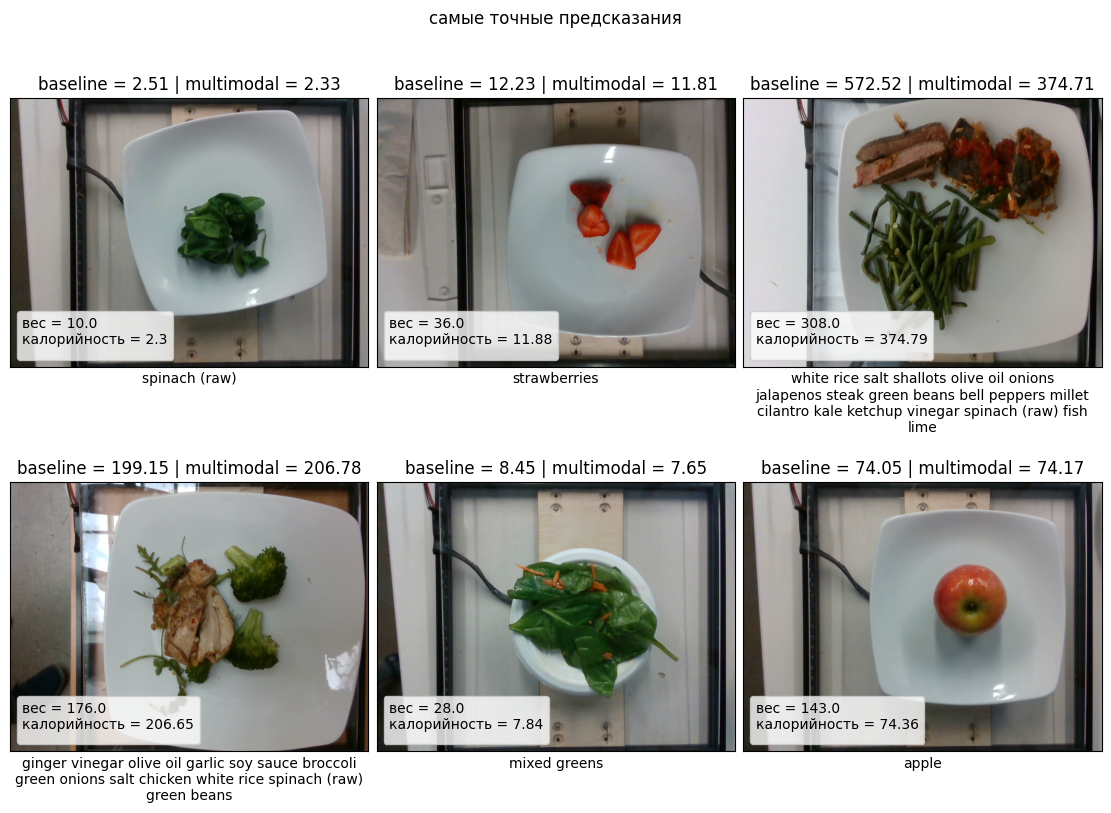

In [63]:
show_top_six(inf_df.sort_values('multimodal_MAE'), 'head')

In [64]:
print('\n', ' '*45, 'САМЫЕ НЕТОЧНЫЕ ПРЕДСКАЗАНИЯ')
inf_df.sort_values('multimodal_MAE').drop(columns=['path_to_photo']).tail(6)


                                               САМЫЕ НЕТОЧНЫЕ ПРЕДСКАЗАНИЯ


,total_mass,descr,total_calories,baseline_pred,multimodal_pred,baseline_MAE,multimodal_MAE,avg_pred,avg_MAE
105,407.0,apple carrot cauliflower almonds,887.823059,529.038330,595.697144,358.784729,292.125915,562.367737,325.455322
71,203.0,almonds white rice spinach (raw),781.958008,596.895752,485.447968,185.062256,296.510040,541.171875,240.786133
445,436.0,chicken cherry tomatoes pizza,901.810059,732.605957,592.923035,169.204102,308.887024,662.764526,239.045533
453,54.0,brownies,251.693985,220.501038,582.511963,31.192947,330.817978,401.506500,149.812515
447,500.0,pizza cherry tomatoes chicken pineapple olives,941.609985,680.640625,610.695007,260.969360,330.914978,645.667847,295.942138
446,488.0,cherry tomatoes pizza chicken pineapple,927.809998,673.232300,574.729187,254.577698,353.080811,623.980713,303.829285


c:\Users\aseva\Desktop\MyEDU\YaDLE\YaDLE_gensim_vscode_stream_4\scripts\utils.py:157: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left',


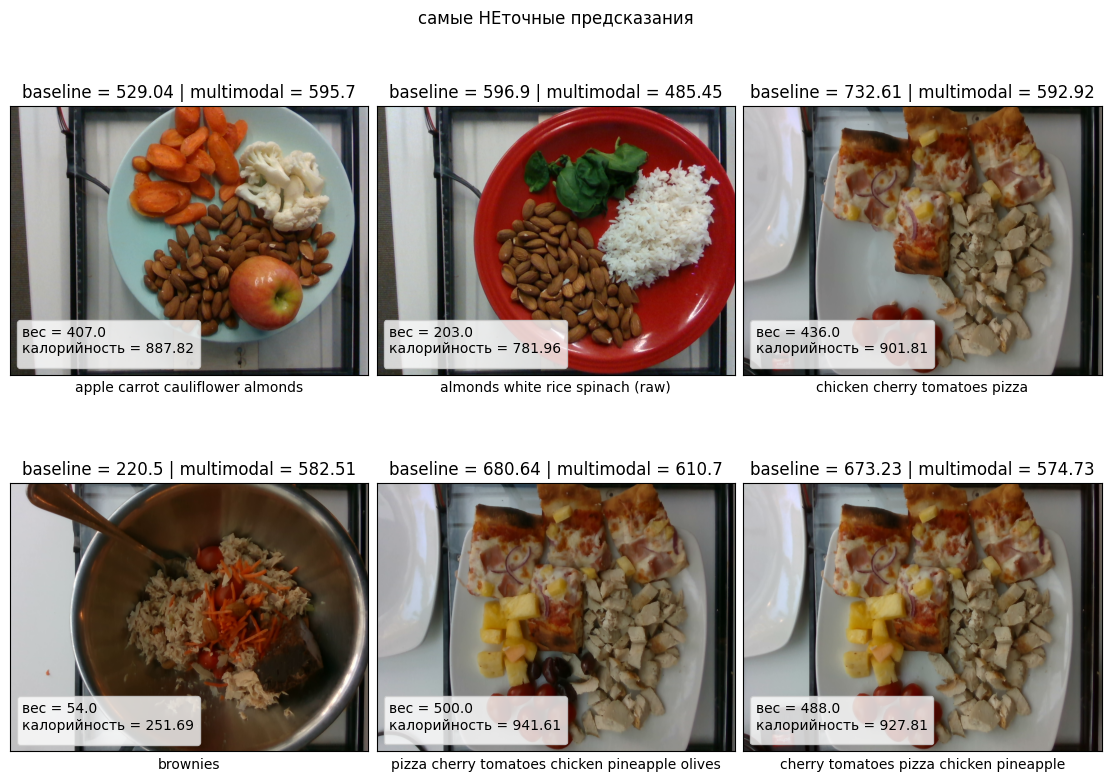

In [65]:
show_top_six(inf_df.sort_values('multimodal_MAE'), 'tail')

## ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ:
* факторы, способствующие точному предсказанию калорийности:
  * только один ингредиент - и в описании и на картинке
  * раздельное расположение ингредиентов на картинке
* факторы, вызывающие ошибки в предсказании калорийности
  * несоответствие картинки и описания - пример brownies, а на картинке сложный салат.  Кстати тут baseline модель, не использующая картинку, точно определяет калорийность, а мультимодальная модель ориентируется больше на картинку и сильно завышает калорийность
  * блюда, которые сервируются при одном составе по разному - пример три пиццы: ни по описанию, ни по картинке не понятно, что это не кусок пиццы, а цыпленок с кусками пиццы в качестве хлеба.  Закономерный результат - врут обе модели, занижая калорийность (никто не наваливает столько курицы на саму пиццу!) 
  * составные блюда, в составе которых сильный дисбаланс высококалорийного компонента - пример две тарелки с кучей миндаля (обычно орехи добавляются в составное блюдо в куда более скромных количествах!)
* потенциал DL-фич ниже в данном конкретном кейсе, чем потенциал векторизации по компонентному составу - так как ML-модель решает задачу определения массовых долей компонент в блюде (даны суммарная масса и суммарная калорийность - есть 200 компонент и 3000 объектов, по факту мы статистически ищем сколько каждого компонента в каждом блюде) - эта семантика напрочь отсутствует в DL-модели, именно поэтому ML-модели дают большую точность: даже HGBoost уверенно приближается к целевому MAE, нейронка же роняет МАЕ почти на 15 на той же ML-векторизации.
* однако ML и DL модели оценивают объекты принципиально по разным фичам, что дало доказанный потенциал для построения комбинированной модели - даже простое усреднение предсказаний двух моделей повысило точность по сравнению с обеими по отдельности:
  * `linear regres ML` MAE  = 56.5
  * `HXBoost model ML` MAE  = 51.7
  * `best baseline ML` MAE  = 37.8
  * `best  multimodal` MAE  = 46.1
  * `avg best  models` MAE  = 35.5